In [1]:
]activate ../../../

  Activating project at `~/UCLOneDrive/SpatialStructureInMicrobialCommunities/SSMCCode`


In [14]:
using Revise
includet("./base.jl")

In [3]:
includet("../../../scripts/figures_util.jl")

using GLMakie
using CairoMakie
CairoMakie.activate!()

# Solving SI ODEs

In [627]:
close(f)
empty(Out)
GC.gc()

In [647]:
df = solve_si_odes("kaka2.jld2", 10,
    3., 1., 1.,
    1e8, 1e-9;
    solver=QNDF,
    # solver=TRBDF2,
);

Progress: 100%|█████████████████████████████████████████| Time: 0:00:02


# Reports for cluster runs

In [596]:
f = jldopen("./main2/ri1.jld2")
df = f["df"]
# df = @subset df :retcodes .== ReturnCode.Success
df = @subset df :maxresids .< 1e-10
fmd = f["metadata"];
N = fmd.N
M = fmd.M

nrow(df), fmd.num_runs

(99, 100)

In [602]:
ks = range(0.01, 100, 1000)
for gi in 1:5
    f = jldopen("./main2/ri$gi.jld2")
    df = f["df"]
    fmd = f["metadata"];
    N = fmd.N
    M = fmd.M

    # df = @subset df :retcodes .== ReturnCode.Success
    df = @subset df :maxresids .< 1e-10
    @show nrow(df), fmd.num_runs

    fit_ds!(df, ks, fmd.T, fmd.K, fmd.l, fmd.p);
    add_mm_mrls!(df, ks, fmd.T, fmd.K, fmd.l, fmd.p);
    
    @show count(df.spatially_unstable)

    fap = scatter(df.num_surv, 1 ./ df.fit_ds;
        # color=clamp.(df.mmrls, minimum(filter(isposdef, df.mmrls); init=0.), Inf),
        # colorscale=log10,
    )
    # Colorbar(fap.figure[1,2], fap.plot;
        # label="max(real(lambdas)) - peak height"
    # )

    fap.axis.xlabel = "Number of surviving species"
    fap.axis.ylabel = "1 / fitted d parameter"

    mm = maximum(df.num_surv)
    lines!(fap.axis, [0., mm], [0., mm]; color=:black)

    Makie.save("./main2/corr_ri$gi.pdf", fap)
end

(nrow(df), fmd.num_runs) = (99, 100)
count(df.spatially_unstable) = 0
(nrow(df), fmd.num_runs) = (92, 100)


┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consider using a method for stiff equations. See the solver pages for more details (e.g. https://docs.sciml.ai/DiffEqDocs/stable/solvers/ode_solve/#Stiff-Problems).
└ @ SciMLBase ~/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:626
┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consider using a method for stiff equations. See the solver pages for more details (e.g. https://docs.sciml.ai/DiffEqDocs/stable/solvers/ode_solve/#Stiff-Problems).
└ @ SciMLBase ~/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:626
┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consid

count(df.spatially_unstable) = 88
(nrow(df), fmd.num_runs) = (85, 100)
count(df.spatially_unstable) = 83
(nrow(df), fmd.num_runs) = (91, 100)
count(df.spatially_unstable) = 87
(nrow(df), fmd.num_runs) = (90, 100)
count(df.spatially_unstable) = 80


# Looking at one dataset tests

In [15]:
f = jldopen("./main2/ri2.jld2")
df = f["df"]
df = @subset df :retcodes .== ReturnCode.Success
fmd = f["metadata"];
nrow(df), fmd.num_runs

(99, 100)

In [16]:
df = df[1:10,:];

In [17]:
ks = range(0.01, 100, 1000)
add_disprels!(df, ks);

In [29]:
fit_ds!(df, ks, fmd.T, fmd.K, fmd.l, fmd.p)
add_mm_mrls!(df, ks, fmd.T, fmd.K, fmd.l, fmd.p);

┌ Warning: Interrupted. Larger maxiters is needed. If you are using an integrator for non-stiff ODEs or an automatic switching algorithm (the default), you may want to consider using a method for stiff equations. See the solver pages for more details (e.g. https://docs.sciml.ai/DiffEqDocs/stable/solvers/ode_solve/#Stiff-Problems).
└ @ SciMLBase ~/.julia/packages/SciMLBase/RPW6n/src/integrator_interface.jl:626


In [30]:
xx = copy(df.fit_ds);

In [31]:
fit_ds_analytic!(df, ks, fmd.K, fmd.l, fmd.p)
add_mm_mrls_analytic!(df, ks, fmd.K, fmd.l, fmd.p);

In [ ]:
df.fit_func = map(df.fit_opt_rs) do opt_r
    opt_r.minimum
end;

In [ ]:
xx = map(df.final_states) do fs
    # std(fs[1:N])
    std(filter(>(1e-9), fs[1:N]))
    nonext = filter(>(1e-9), fs[1:N])
    if isempty(nonext)
        NaN
    else
        ee = extrema(nonext)
        ee[2] - ee[1]
    end
end;
# xx = xx ./ df.num_surv;

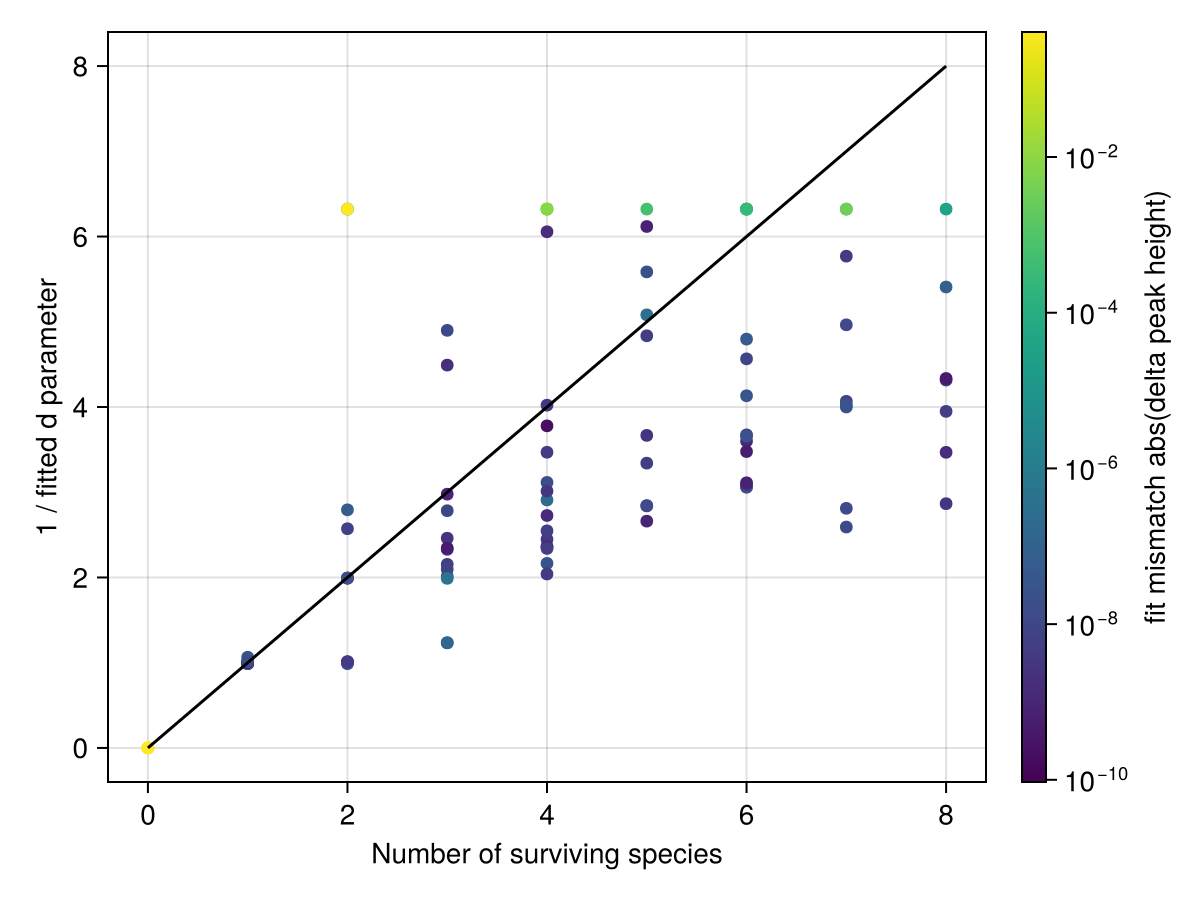

In [657]:
fap = scatter(df.num_surv, 1 ./ df.fit_ds;
    # color=clamp.(df.mmrls, minimum(filter(isposdef, df.mmrls)), Inf),
    # color=clamp.(df.tot_biom, 1e-1, Inf),
    # color=clamp.(xx, 1e-5, Inf),
    # color=xx,
    color=clamp.(df.fit_func, 0., maximum(filter(<(0.9), df.fit_func))),
    # color=df.fit_func,
    colorscale=log10,
)
Colorbar(fap.figure[1,2], fap.plot;
    # label="max(real(lambdas)) - peak height"
    label="fit mismatch abs(delta peak height)"
)

fap.axis.xlabel = "Number of surviving species"
fap.axis.ylabel = "1 / fitted d parameter"

mm = maximum(df.num_surv)
lines!(fap.axis, [0., mm], [0., mm]; color=:black)

Makie.save("./num_surv_vs_invd_base.pdf", fap)
fap

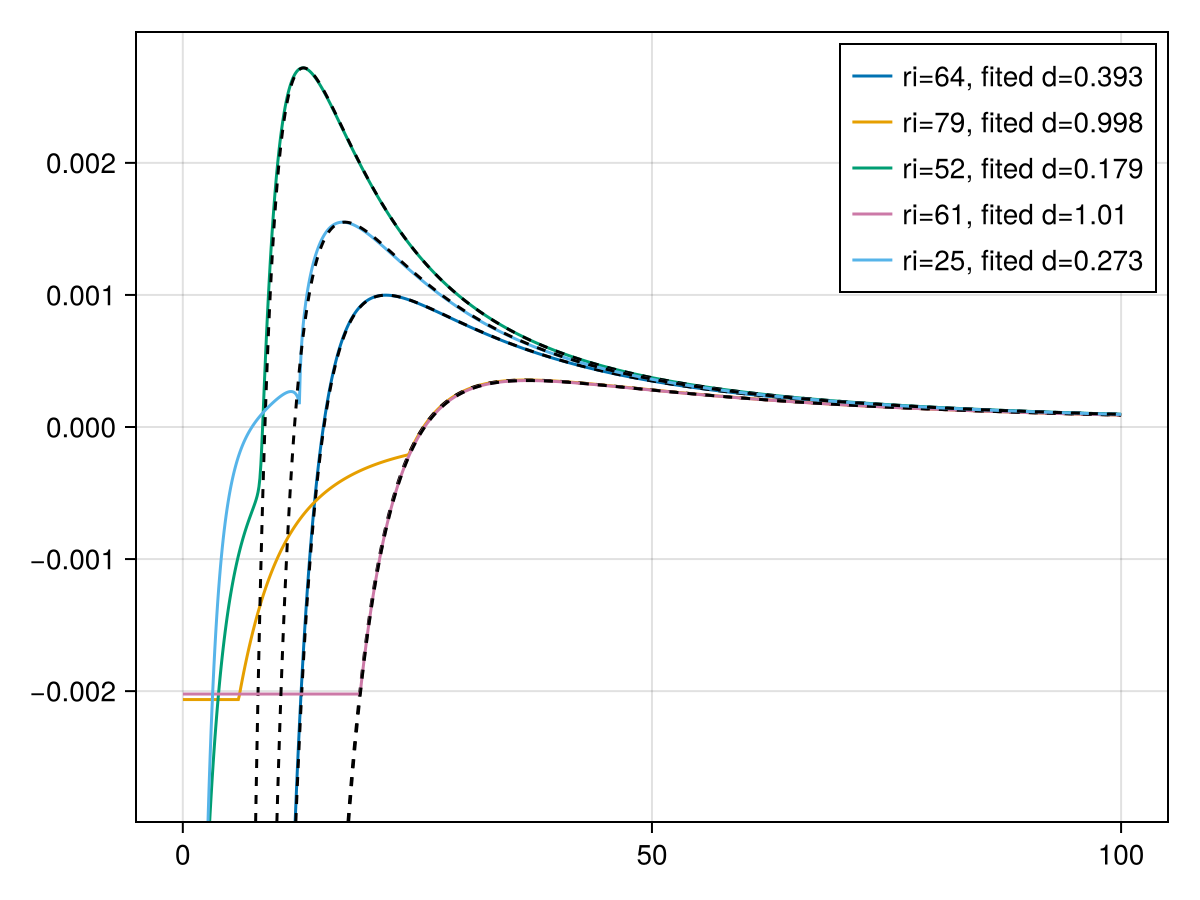

In [665]:
fig = plot_fitted_disprels(df, ks, 5;
    legend=true
)
Makie.save("./fitted_disprel1.pdf", fig)
fig

In [532]:
xx = (1 ./ df.fit_ds) .- df.num_surv
sp = sortperm(xx; rev=true)
collect(zip(sp, xx[sp]))[1:5]
# findall(isposdef, (1 ./ df.fit_ds) .- df.num_surv)

5-element Vector{Tuple{Int64, Float64}}:
 (62, 1.441935372949347)
 (77, 1.441935372949347)
 (16, 1.009546833413422)
 (25, 0.4419353729493469)
 (47, 0.4419353729493469)

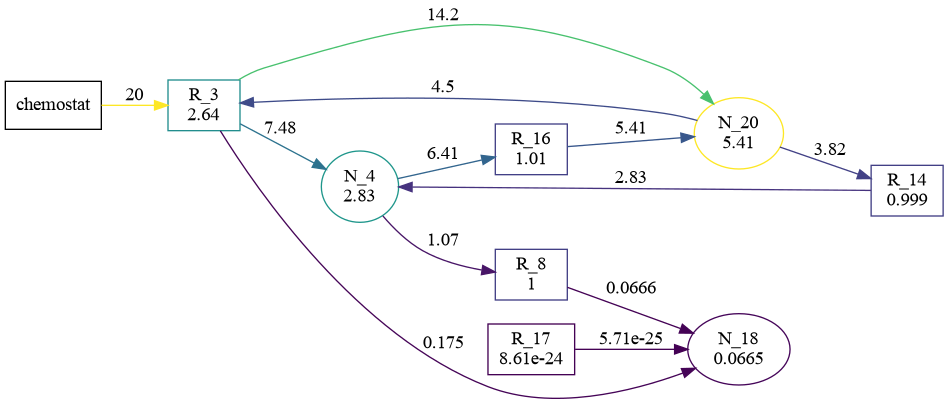

In [485]:
diagram_sfss_v3(r.params, r.final_states; strain_threshold=1e-2)

r.fit_ds = 0.22512709349393845
r.maxresids = 3.170796958329447e-13


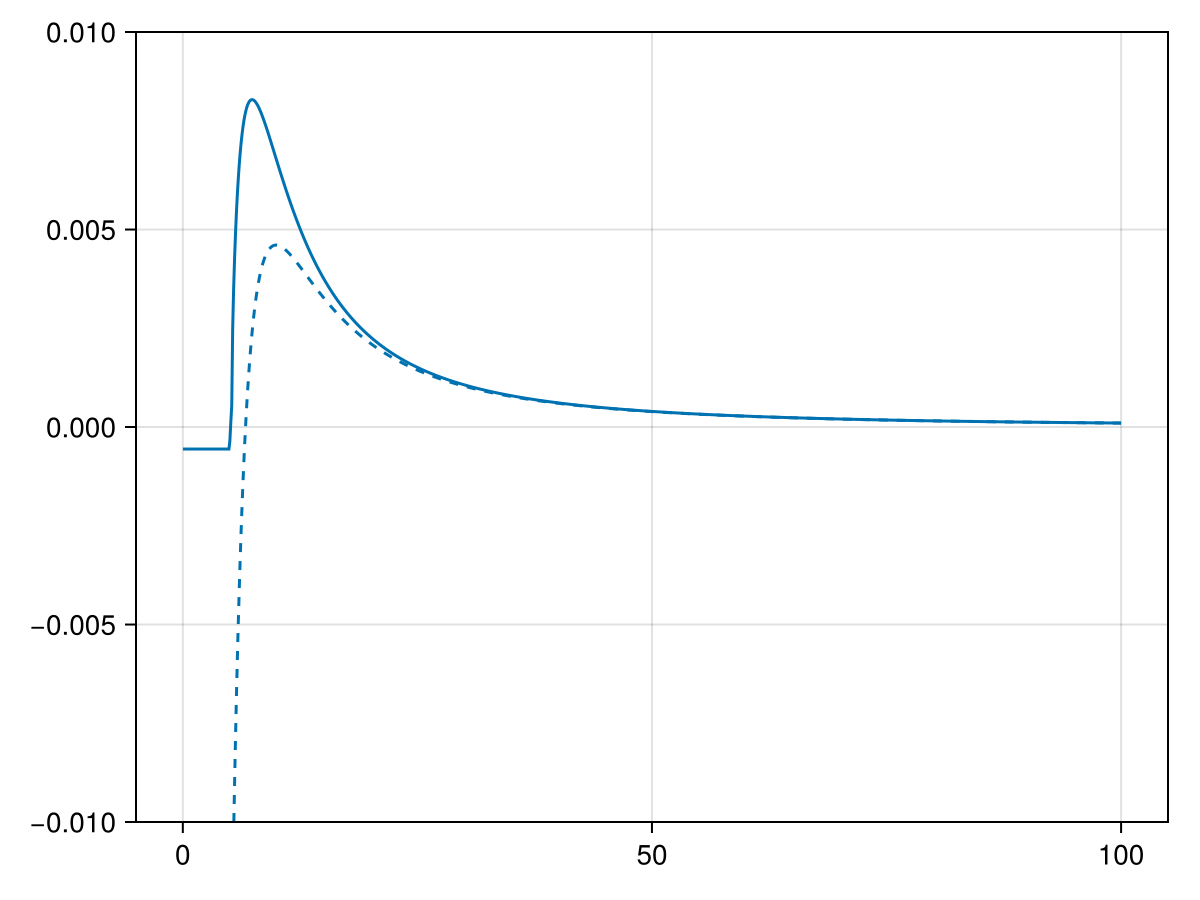

In [482]:
fig = Figure()
ax = Axis(fig[1,1])

r = df[62,:]
@show r.fit_ds r.maxresids

lines!(ks, r.mrls)
lines!(ks, r.mm_mrls;
    color=Cycled(1),
    linestyle=:dash,
)

ylims!(ax, -0.01, 0.01)

fig

# Finding the limits on d

In [707]:
mmp = MMParams(;
    fmd.K, fmd.l,
    m=1., c=1.,
    d=1.,
)

MMParams{Float64}(27.371708245126285, 1.0, 1.0, 0.999, 1.0, 0.0, 1.0)

In [746]:
MinimalModelV2.get_mm_the_nonext_sol(mmp)

3-element Vector{Float64}:
 25.333314995291605
  1.0394326825171971
  0.9989605673174827

In [722]:
mm_ps = mmp_to_mmicrm(mmp; static=false)
mm_p = make_mmicrm_problem(mm_ps, [100., 0., 0.], 1e8)
tol=1e-9
s = solve(mm_p, QNDF();
    callback=CallbackSet(make_timer_callback(10), PositiveDomain([1., 0., 0.])),
    abstol=tol,
    reltol=tol,
);
s.u[end]

3-element Vector{Float64}:
 25.333314995291605
  1.0394326825171971
  0.9989605673174828